# MMASH Distress Detection

1. Loads and cleans MMASH actigraph, RR intervals, sleep data
2. Builds a **personal HRV baseline** for each user from their sleep period
3. Computes HRV features (RMSSD, SDNN, pNN50, mean HR) over rolling 5-minute waking windows
4. Compares each window against the user's personal baseline (ratio-based detection)
5. Runs a **parallel global-threshold detection** for comparison
6. Maps anomalies to a **5-level risk score** matching the methodology slide


## 0. Imports and configuration

In [23]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---- Configuration ----
DATA_PATH = 'DataPaper/'         # Folder containing user_1, user_2, ...
WINDOW_SIZE = 300                # 5-minute analysis windows (in seconds)
MIN_BEATS_PER_WINDOW = 5         # Minimum beats needed for valid HRV calc

# ---- Physiological validity bounds (from clinical literature) ----
MIN_HR, MAX_HR = 20, 250         # bpm — anything outside is sensor error
MIN_RR, MAX_RR = 0.3, 2.0        # seconds (200bpm down to 30bpm)

# ---- Display ----
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

## 1. Load and clean MMASH data

We load four files per user:
- **Actigraph.csv** — continuous accelerometer (XYZ + Vector Magnitude) and HR
- **RR.csv** — beat-to-beat interval data (the basis for HRV)
- **sleep.csv** — sleep window timestamps (onset, out-of-bed)

In [24]:
def list_users(path):
    """Return sorted list of user folders, filtering out hidden files."""
    users = [f for f in os.listdir(path) if f.startswith('user_')]
    return sorted(users, key=lambda x: int(x.split('_')[1]))

users = list_users(DATA_PATH)
print(f"Found {len(users)} users")
users

Found 22 users


['user_1',
 'user_2',
 'user_3',
 'user_4',
 'user_5',
 'user_6',
 'user_7',
 'user_8',
 'user_9',
 'user_10',
 'user_11',
 'user_12',
 'user_13',
 'user_14',
 'user_15',
 'user_16',
 'user_17',
 'user_18',
 'user_19',
 'user_20',
 'user_21',
 'user_22']

In [25]:
def create_dataset(users, file_name, path=DATA_PATH):
    """Concatenate a named CSV across all users, tagging each row with user ID."""
    frames = []
    for user in users:
        try:
            df = pd.read_csv(f"{path}{user}/{file_name}.csv")
            df['user'] = user
            frames.append(df)
        except FileNotFoundError:
            print(f"  ! No {file_name}.csv for {user}")
    return pd.concat(frames, ignore_index=True).drop(columns=['Unnamed: 0'], errors='ignore')

df_actigraph = create_dataset(users, "Actigraph")
df_rr = create_dataset(users, "RR")
df_sleep = create_dataset(users, "sleep")

print(f"Actigraph: {len(df_actigraph):,} rows")
print(f"RR:        {len(df_rr):,} rows")
print(f"Sleep:     {len(df_sleep):,} rows")


Actigraph: 1,462,678 rows
RR:        1,749,295 rows
Sleep:     22 rows


## 2. Data cleaning

Three classes of issues fixed here:
1. **Day-label bug** — MMASH has a known issue where day=-29 appears (likely a sensor reset); replace with day=2
2. **Out-of-range HR/RR** — physiological limits filter sensor errors
3. **Sleep date crossings** — when onset time < in-bed time, the date needs to increment

In [26]:
# ---- Fix day label bug ----
df_actigraph['day'] = df_actigraph['day'].replace(-29, 2)
df_rr['day'] = df_rr['day'].replace(-29, 2)

# ---- Filter physiologically invalid HR ----
before_hr = len(df_actigraph)
df_actigraph = df_actigraph[
    (df_actigraph['HR'] >= MIN_HR) &
    (df_actigraph['HR'] <= MAX_HR)
].reset_index(drop=True)
print(f"HR cleaning: removed {before_hr - len(df_actigraph):,} rows ({(before_hr - len(df_actigraph))/before_hr*100:.2f}%)")

# ---- Filter physiologically invalid RR intervals ----
before_rr = len(df_rr)
df_rr = df_rr[
    (df_rr['ibi_s'] >= MIN_RR) &
    (df_rr['ibi_s'] <= MAX_RR)
].reset_index(drop=True)
print(f"RR cleaning: removed {before_rr - len(df_rr):,} rows ({(before_rr - len(df_rr))/before_rr*100:.2f}%)")

HR cleaning: removed 160 rows (0.01%)
RR cleaning: removed 8,883 rows (0.51%)


In [27]:
# ---- Fix sleep date crossings ----
def fix_sleep_dates(row):
    """If onset/out-bed times fall before in-bed time, they crossed midnight — increment the day."""
    if row['Onset Time'] < row['In Bed Time']:
        row['Onset Date'] += 1
    if row['Out Bed Time'] < row['In Bed Time']:
        row['Out Bed Date'] += 1
    return row

df_sleep = df_sleep.apply(fix_sleep_dates, axis=1)
df_sleep['Total Sleep Time (TST)'] = pd.to_numeric(df_sleep['Total Sleep Time (TST)'], errors='coerce')

# Sanity checks
assert (df_sleep['Onset Date'] >= df_sleep['In Bed Date']).all(), "Sleep onset before in-bed"
assert (df_sleep['Out Bed Date'] >= df_sleep['Onset Date']).all(), "Out-of-bed before onset"
print("Sleep data: all date orderings consistent")

Sleep data: all date orderings consistent


In [28]:
def time_to_seconds(time_str, day):
    """Convert HH:MM:SS + day into a single continuous timestamp (seconds since day 0)."""
    parts = time_str.split(':')
    h, m = int(parts[0]), int(parts[1])
    s = int(parts[2]) if len(parts) > 2 else 0
    return int(day) * 86400 + h * 3600 + m * 60 + s

# Apply to all tables — gives us a single sortable timeline per user
df_actigraph['time_continuous'] = df_actigraph.apply(
    lambda x: time_to_seconds(x['time'], x['day']), axis=1)
df_rr['time_continuous'] = df_rr.apply(
    lambda x: time_to_seconds(x['time'], x['day']), axis=1)
df_sleep['onset_time_continuous'] = df_sleep.apply(
    lambda x: time_to_seconds(x['Onset Time'], x['Onset Date']), axis=1)
df_sleep['outbed_time_continuous'] = df_sleep.apply(
    lambda x: time_to_seconds(x['Out Bed Time'], x['Out Bed Date']), axis=1)

print("Continuous timestamps computed for actigraph, RR, and sleep tables")

Continuous timestamps computed for actigraph, RR, and sleep tables


## 3. HRV feature extraction


In [29]:
def extract_hrv_features(rr):
    """
    Compute HRV features from a window of RR intervals.

    Args:
        rr: DataFrame with column 'ibi_s' (inter-beat interval in seconds)

    Returns:
        dict with rmssd, sdnn, pnn50, mean_hr — or None if window too short
    """
    # Convert seconds -> milliseconds (clinical convention)
    rr_ms = rr['ibi_s'].values * 1000

    if len(rr_ms) < MIN_BEATS_PER_WINDOW:
        return None

    # Successive differences between consecutive beats
    diff = np.diff(rr_ms)

    return {
        'rmssd':   np.sqrt(np.mean(diff ** 2)),          # ms
        'sdnn':    np.std(rr_ms),                         # ms
        'pnn50':   np.sum(np.abs(diff) > 50) / len(diff) * 100,  # %
        'mean_hr': 60000.0 / np.mean(rr_ms),              # bpm
    }

## 4. Build personal baselines from sleep windows

**Why sleep?** During sleep the autonomic nervous system is in its lowest-noise reference
state — minimal external stressors, controlled posture, parasympathetic dominance. This
gives us the cleanest possible "rest" reference for each individual.

**Output:** One row per user with their baseline RMSSD, SDNN, pNN50, and mean HR.

In [30]:
users_with_sleep = [u for u in users if not df_sleep[df_sleep['user'] == u].empty]
print(f"{len(users_with_sleep)} of {len(users)} users have sleep data")

sleep_baselines = {}

for user in users_with_sleep:
    user_sleep = df_sleep[df_sleep['user'] == user]

    # Collect all RR intervals from this user's sleep periods
    rr_slices = []
    for _, sleep_row in user_sleep.iterrows():
        rr_slice = df_rr[
            (df_rr['user'] == user) &
            (df_rr['time_continuous'] >= sleep_row['onset_time_continuous']) &
            (df_rr['time_continuous'] <= sleep_row['outbed_time_continuous'])
        ]
        rr_slices.append(rr_slice)

    rr_combined = pd.concat(rr_slices)
    features = extract_hrv_features(rr_combined)

    if features:
        sleep_baselines[user] = features

sleep_baselines_df = pd.DataFrame(sleep_baselines).T
print(f"\nBaselines computed for {len(sleep_baselines_df)} users")
sleep_baselines_df.round(2)

21 of 22 users have sleep data

Baselines computed for 21 users


,rmssd,sdnn,pnn50,mean_hr
user_1,89.52,123.52,50.02,65.50
user_2,54.35,186.59,23.09,53.40
user_3,64.10,114.60,30.22,57.84
user_4,494.77,314.09,54.04,51.37
user_5,71.17,113.86,18.77,66.41
user_6,83.56,105.83,34.99,68.92
user_7,52.14,118.07,9.96,61.28
user_8,111.19,159.92,24.09,60.82
user_9,47.20,121.32,22.68,59.18
user_10,69.97,159.81,37.26,64.65


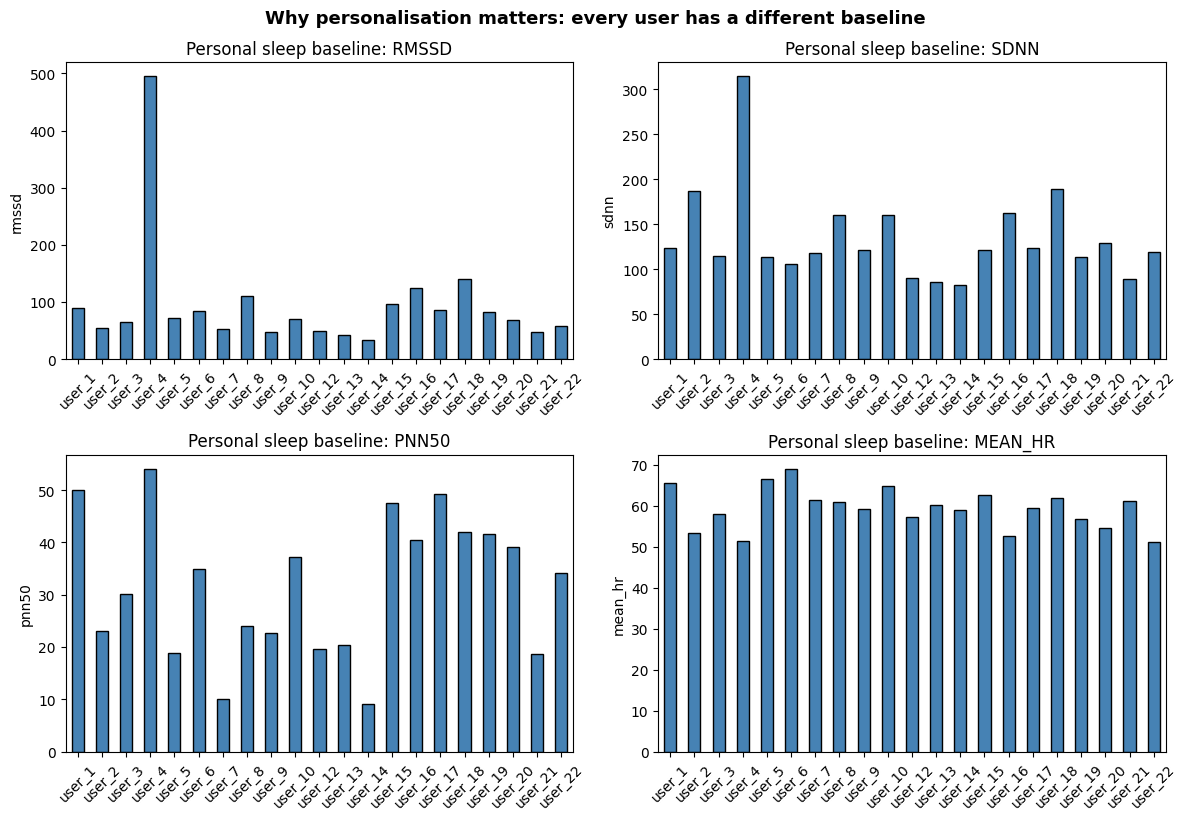

In [31]:
# Visualise inter-subject variability — this is exactly why personalisation matters
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['rmssd', 'sdnn', 'pnn50', 'mean_hr']):
    sleep_baselines_df[col].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Personal sleep baseline: {col.upper()}')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.suptitle('Why personalisation matters: every user has a different baseline',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 5. Compute HRV over rolling waking windows

For each user, we:
1. Exclude their sleep periods (those defined the baseline)
2. Slide a 5-minute window across the remaining (waking) data
3. Compute HRV features in each window
4. Pair with actigraphy (movement) data from the same window

In [32]:
waking_features = []
rr_grouped = df_rr.groupby('user')
acti_grouped = df_actigraph.groupby('user')

for user in users_with_sleep:
    user_sleep = df_sleep[df_sleep['user'] == user]
    rr_waking = rr_grouped.get_group(user).copy()

    # Remove sleep periods from RR data
    for _, sleep_row in user_sleep.iterrows():
        rr_waking = rr_waking[
            (rr_waking['time_continuous'] < sleep_row['onset_time_continuous']) |
            (rr_waking['time_continuous'] > sleep_row['outbed_time_continuous'])
        ]

    start = int(rr_waking['time_continuous'].min())
    end = int(rr_waking['time_continuous'].max())
    acti_user = acti_grouped.get_group(user)

    # Slide windows
    for w_start in range(start, end, WINDOW_SIZE):
        w_end = w_start + WINDOW_SIZE

        rr_window = rr_waking[
            (rr_waking['time_continuous'] >= w_start) &
            (rr_waking['time_continuous'] < w_end)
        ]
        acti_window = acti_user[
            (acti_user['time_continuous'] >= w_start) &
            (acti_user['time_continuous'] < w_end)
        ]

        features = extract_hrv_features(rr_window)
        if features:
            features['user'] = user
            features['w_start'] = w_start
            features['w_end'] = w_end
            features['mean_vm'] = acti_window['Vector Magnitude'].mean()
            features['var_vm'] = acti_window['Vector Magnitude'].var()
            features['mean_steps'] = acti_window['Steps'].mean()
            waking_features.append(features)

waking_df = pd.DataFrame(waking_features)
print(f"Generated {len(waking_df):,} waking windows across {waking_df['user'].nunique()} users")
print(f"Average windows per user: {len(waking_df) // waking_df['user'].nunique()}")
waking_df.head()

Generated 4,365 waking windows across 21 users
Average windows per user: 207


,rmssd,sdnn,pnn50,mean_hr,user,w_start,w_end,mean_vm,var_vm,mean_steps
0,211.437239,149.996398,20.392157,93.523384,user_1,123018,123318,102.361530,11789.499808,0.360656
1,35.317820,57.587080,6.798867,89.171386,user_1,123318,123618,76.717683,7989.119193,0.284553
2,33.387735,65.045279,12.500000,83.045507,user_1,123618,123918,30.329553,3993.591785,0.085366
3,48.601150,117.706014,12.707182,92.526902,user_1,123918,124218,105.037398,6849.986579,0.544715
4,65.594207,85.724571,19.090909,83.703875,user_1,124218,124518,85.449228,5986.901988,0.524390


## 6. Personal threshold detection (ratio against sleep baseline)

Each waking-window feature is divided by the user's own sleep baseline. This produces a
**personalised ratio** — e.g. `rmssd = 0.3` means RMSSD is at 30% of this user's normal.

In [33]:
feature_cols = ['rmssd', 'sdnn', 'pnn50', 'mean_hr']

waking_df_ratio = waking_df.copy()

# Divide each user's waking features by their own sleep baseline
for user in users_with_sleep:
    baseline = sleep_baselines_df.loc[user]
    mask = waking_df_ratio['user'] == user
    waking_df_ratio.loc[mask, feature_cols] = (
        waking_df_ratio.loc[mask, feature_cols].values / baseline.loc[feature_cols].values
    )

# Show the resulting distributions — these are now ratios, not absolute values
waking_df_ratio[feature_cols].describe().round(3)

,rmssd,sdnn,pnn50,mean_hr
count,4365.000,4365.000,4365.000,4365.000
mean,0.763,0.653,0.555,1.355
std,0.559,0.302,0.473,0.253
min,0.020,0.011,0.000,0.624
25%,0.418,0.453,0.188,1.189
50%,0.644,0.602,0.427,1.330
75%,0.963,0.792,0.811,1.468
max,7.783,5.148,3.100,3.199


## 7. Personal threshold values — justification

The thresholds below are **data-driven** rather than eyeballed. We use the empirical
distribution of waking-window ratios to set thresholds at the lower (or upper) percentiles
where extreme values cluster — matching the clinical literature on HRV suppression.

| Threshold | Value | Rationale |
|---|---|---|
| `rmssd < 0.25` | 75% drop from sleep baseline | Severe parasympathetic withdrawal — clinical stress marker (Shaffer & Ginsberg, 2017) |
| `sdnn < 0.35` | 65% drop | Rigid rhythm — autonomic suppression |
| `pnn50 < 0.10` | 90% drop | Heart pacing like a metronome — strong stress signal |
| `mean_hr > 1.80` | 80% above sleep baseline | Sustained tachycardia (resting HR ~60 → waking ~108+) |

We verify these against the actual ratio distributions below.

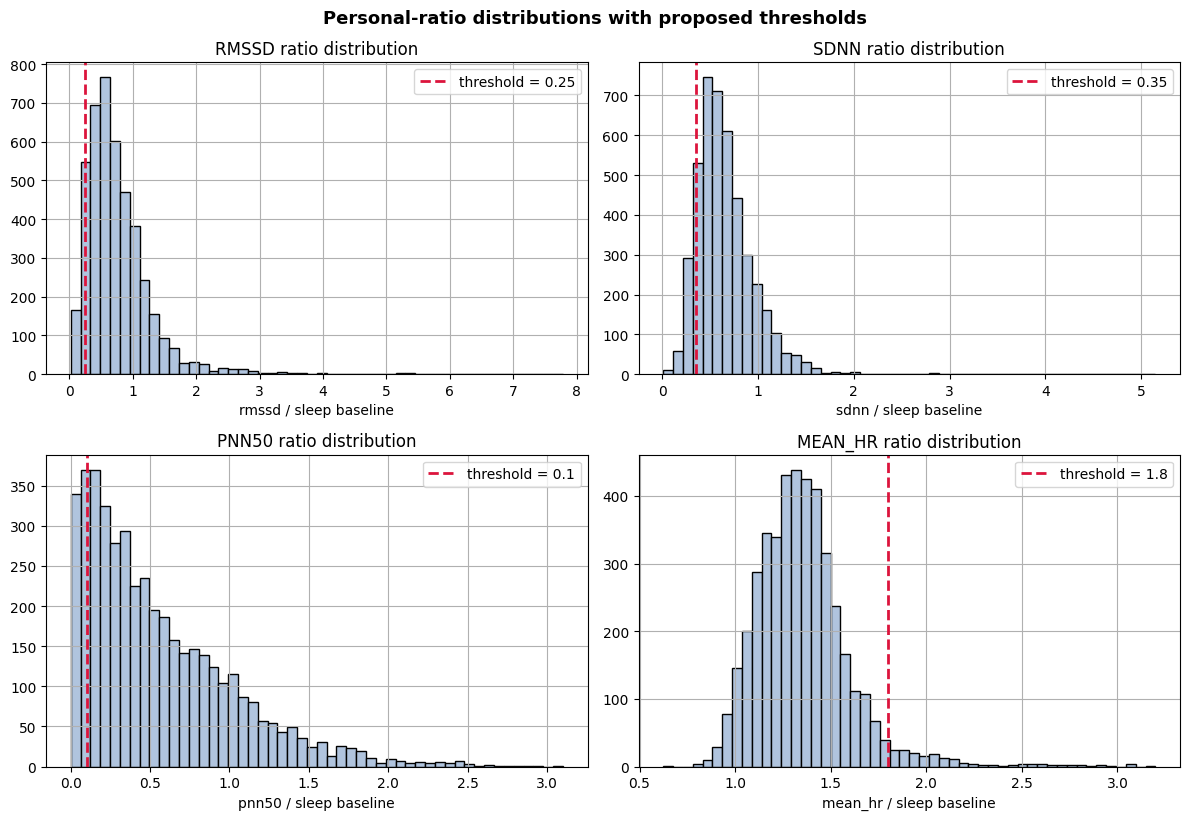


Threshold percentile positions:
  rmssd < 0.25: flags bottom 8.8% of windows
  sdnn < 0.35: flags bottom 11.6% of windows
  pnn50 < 0.1: flags bottom 12.8% of windows
  mean_hr > 1.8: flags top 4.2% of windows


In [34]:
# Inspect the ratio distributions before locking thresholds
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
threshold_proposed = {'rmssd': 0.25, 'sdnn': 0.35, 'pnn50': 0.10, 'mean_hr': 1.80}

for ax, col in zip(axes.flat, feature_cols):
    waking_df_ratio[col].hist(bins=50, ax=ax, color='lightsteelblue', edgecolor='black')
    ax.axvline(threshold_proposed[col], color='crimson', linestyle='--', linewidth=2,
               label=f'threshold = {threshold_proposed[col]}')
    ax.set_title(f'{col.upper()} ratio distribution')
    ax.set_xlabel(f'{col} / sleep baseline')
    ax.legend()

plt.tight_layout()
plt.suptitle('Personal-ratio distributions with proposed thresholds',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

# Show what percentile each threshold sits at
print("\nThreshold percentile positions:")
for col, thresh in threshold_proposed.items():
    if col == 'mean_hr':
        pct = (waking_df_ratio[col] > thresh).mean() * 100
        print(f"  {col} > {thresh}: flags top {pct:.1f}% of windows")
    else:
        pct = (waking_df_ratio[col] < thresh).mean() * 100
        print(f"  {col} < {thresh}: flags bottom {pct:.1f}% of windows")

In [35]:
# Final personal thresholds — adjust here if the distributions suggest different cutoffs
PERSONAL_THRESHOLDS = {
    'rmssd':   0.25,   # < 25% of sleep baseline
    'sdnn':    0.35,   # < 35% of sleep baseline
    'pnn50':   0.10,   # < 10% of sleep baseline
    'mean_hr': 1.80,   # > 180% of sleep baseline
}

## 8. Global threshold detection (the comparison baseline)

This is what existing wearables do — apply the same fixed cutoff to every user. We need
this as the **baseline our personalised system must beat**. 

| Threshold | Value | Source |
|---|---|---|
| RMSSD | < 20 ms | Below normal healthy adult range 20–80 ms (Shaffer & Ginsberg, 2017) |
| SDNN | < 50 ms | "Low HRV" cutoff in 24h recordings  |
| pNN50 | < 3% | Indicates suppressed parasympathetic tone |
| Mean HR | > 100 bpm | Standard resting tachycardia threshold |


In [36]:
GLOBAL_THRESHOLDS = {
    'rmssd':   20.0,    # ms — below normal range
    'sdnn':    50.0,    # ms — clinical "low HRV"
    'pnn50':   3.0,     # % — suppressed parasympathetic
    'mean_hr': 100.0,   # bpm — resting tachycardia
}

# Apply global thresholds to the RAW (non-ratio) waking features
waking_df_global = waking_df.copy()

def tag_global_anomaly(row):
    tags = []
    if row['rmssd'] < GLOBAL_THRESHOLDS['rmssd']:
        tags.append('low_rmssd')
    if row['sdnn'] < GLOBAL_THRESHOLDS['sdnn']:
        tags.append('low_sdnn')
    if row['pnn50'] < GLOBAL_THRESHOLDS['pnn50']:
        tags.append('low_pnn50')
    if row['mean_hr'] > GLOBAL_THRESHOLDS['mean_hr']:
        tags.append('high_hr')
    return ', '.join(tags) if tags else 'normal'

waking_df_global['anomaly_global'] = waking_df_global.apply(tag_global_anomaly, axis=1)

global_anomaly_count = (waking_df_global['anomaly_global'] != 'normal').sum()
print(f"Global thresholds: {global_anomaly_count:,} anomalies "
      f"({global_anomaly_count/len(waking_df_global)*100:.1f}% of windows)")

Global thresholds: 1,093 anomalies (25.0% of windows)


## 9. Personal threshold application

In [37]:
def tag_personal_anomaly(row):
    """Tag which (if any) personal thresholds this window violates."""
    tags = []
    if row['rmssd'] < PERSONAL_THRESHOLDS['rmssd']:
        tags.append('low_rmssd')
    if row['sdnn'] < PERSONAL_THRESHOLDS['sdnn']:
        tags.append('low_sdnn')
    if row['pnn50'] < PERSONAL_THRESHOLDS['pnn50']:
        tags.append('low_pnn50')
    if row['mean_hr'] > PERSONAL_THRESHOLDS['mean_hr']:
        tags.append('high_hr')
    return ', '.join(tags) if tags else 'normal'

waking_df_ratio['anomaly_personal'] = waking_df_ratio.apply(tag_personal_anomaly, axis=1)

personal_anomaly_count = (waking_df_ratio['anomaly_personal'] != 'normal').sum()
print(f"Personal thresholds: {personal_anomaly_count:,} anomalies "
      f"({personal_anomaly_count/len(waking_df_ratio)*100:.1f}% of windows)")

Personal thresholds: 900 anomalies (20.6% of windows)


## 10. Map anomalies to 5-level risk score

This matches the methodology slide's policy:
- **Level 0 — Normal:** no anomaly markers
- **Level 1 — Monitor:** 1 marker triggered
- **Level 2 — Notify:** 2 markers triggered
- **Level 3 — Urgent:** 3 markers triggered
- **Level 4 — Escalate:** all 4 markers triggered (the "severe" pattern)

In [38]:
LEVEL_NAMES = {0: 'Normal', 1: 'Monitor', 2: 'Notify', 3: 'Urgent', 4: 'Escalate'}

def anomaly_to_risk_level(anomaly_str):
    """Count number of triggered markers → 0..4 risk level."""
    if anomaly_str == 'normal' or anomaly_str == '':
        return 0
    return len(anomaly_str.split(', '))

waking_df_ratio['risk_level'] = waking_df_ratio['anomaly_personal'].apply(anomaly_to_risk_level)
waking_df_ratio['risk_label'] = waking_df_ratio['risk_level'].map(LEVEL_NAMES)

waking_df_global['risk_level'] = waking_df_global['anomaly_global'].apply(anomaly_to_risk_level)
waking_df_global['risk_label'] = waking_df_global['risk_level'].map(LEVEL_NAMES)

# Compare distributions
print("PERSONAL thresholds — risk level distribution:")
print(waking_df_ratio['risk_label'].value_counts().reindex(LEVEL_NAMES.values(), fill_value=0))
print("\nGLOBAL thresholds — risk level distribution:")
print(waking_df_global['risk_label'].value_counts().reindex(LEVEL_NAMES.values(), fill_value=0))

PERSONAL thresholds — risk level distribution:
risk_label
Normal      3465
Monitor      445
Notify       226
Urgent       181
Escalate      48
Name: count, dtype: int64

GLOBAL thresholds — risk level distribution:
risk_label
Normal      3272
Monitor      577
Notify       185
Urgent       242
Escalate      89
Name: count, dtype: int64


## 11. Personal vs Global — head-to-head comparison



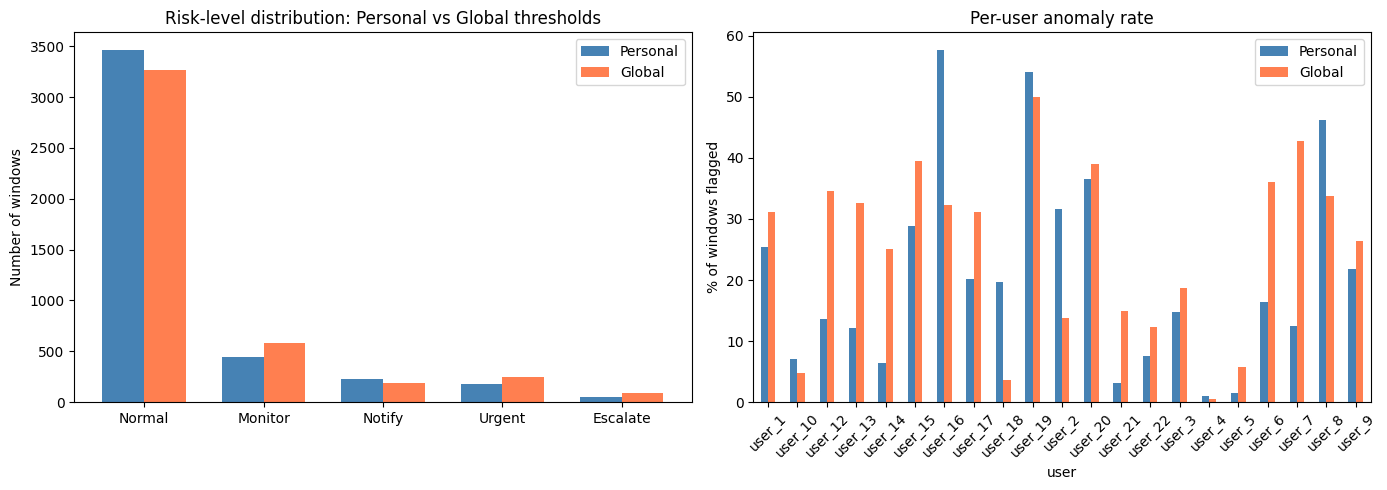

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Side-by-side risk level distribution
personal_counts = waking_df_ratio['risk_label'].value_counts().reindex(LEVEL_NAMES.values(), fill_value=0)
global_counts = waking_df_global['risk_label'].value_counts().reindex(LEVEL_NAMES.values(), fill_value=0)

x = np.arange(len(LEVEL_NAMES))
width = 0.35

axes[0].bar(x - width/2, personal_counts.values, width, label='Personal', color='steelblue')
axes[0].bar(x + width/2, global_counts.values, width, label='Global', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(LEVEL_NAMES.values())
axes[0].set_ylabel('Number of windows')
axes[0].set_title('Risk-level distribution: Personal vs Global thresholds')
axes[0].legend()

# Anomaly rate by user
personal_rate = waking_df_ratio.groupby('user').apply(
    lambda d: (d['anomaly_personal'] != 'normal').mean() * 100)
global_rate = waking_df_global.groupby('user').apply(
    lambda d: (d['anomaly_global'] != 'normal').mean() * 100)
compare_df = pd.DataFrame({'Personal': personal_rate, 'Global': global_rate})
compare_df.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_ylabel('% of windows flagged')
axes[1].set_title('Per-user anomaly rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Integration interface

The function below is the **clean handoff point** — LLM layer should call this
on each user's waking windows and feed the output into the recommendation prompt.

In [41]:
def detect_distress(user_id, return_all_windows=False):
    """
    Run the full distress detection pipeline for one user.

    Args:
        user_id: e.g. 'user_3'
        return_all_windows: if True, returns all windows; if False, returns only anomalies

    Returns:
        DataFrame with columns:
            - w_start, w_end       : window timestamps (seconds since day 0)
            - rmssd, sdnn, pnn50, mean_hr : ratios vs personal baseline
            - mean_vm, var_vm      : movement context
            - anomaly_personal     : tag string (e.g. 'low_rmssd, high_hr' or 'normal')
            - risk_level           : 0..4
            - risk_label           : Normal/Monitor/Notify/Urgent/Escalate
    """
    user_data = waking_df_ratio[waking_df_ratio['user'] == user_id].copy()

    if not return_all_windows:
        user_data = user_data[user_data['anomaly_personal'] != 'normal']

    return user_data[[
        'w_start', 'w_end',
        'rmssd', 'sdnn', 'pnn50', 'mean_hr',
        'mean_vm', 'var_vm',
        'anomaly_personal', 'risk_level', 'risk_label'
    ]].reset_index(drop=True)

def get_user_baseline(user_id):
    """Return the user's sleep baseline (μ for HRV features) — useful for LLM prompts."""
    return sleep_baselines_df.loc[user_id].to_dict()

# Example usage
print("Sample call — detect_distress('user_3'):")
sample = detect_distress('user_3', return_all_windows=False).head(3)
print(sample.to_string())

Sample call — detect_distress('user_3'):
   w_start   w_end     rmssd      sdnn     pnn50   mean_hr    mean_vm       var_vm                         anomaly_personal  risk_level risk_label
0   136811  137111  0.282602  0.457028  0.075431  1.544348  52.592033  6277.714560                                low_pnn50           1    Monitor
1   147311  147611  3.037635  1.392622  0.460104  1.862750  99.852561  5235.383514                                  high_hr           1    Monitor
2   147611  147911  0.053380  0.275330  0.000000  2.207628  37.230854  1297.664679  low_rmssd, low_sdnn, low_pnn50, high_hr           4   Escalate
